# Power spectral density (PSD) of a kinetic-energy time series

Interactive companion to [`psd_KineticEnergy.py`](psd_KineticEnergy.py).

It reads a per-run `KineticEnergy_timeSeries.npz` (produced by
`batch_KineticEnergy.py`, containing `t`, `Ek_frame` and the PIV sampling
frequency `fps`), estimates the **PSD** of `Ek(t)` with Welch's method
(`scipy.signal.welch`), and draws two panels:

1. the kinetic-energy time series `Ek(t)`;
2. its PSD versus frequency.

Welch averages the periodograms of overlapping windowed segments (length
`NPERSEG`, 50% overlap), trading frequency resolution for a smoother,
lower-variance estimate than the raw periodogram. By default the mean is removed
per segment so the DC term does not dwarf the rest. If the libration frequency
can be parsed from the run name, dashed guides are drawn at `flib` and `2*flib`.

Run with an environment that has **numpy / scipy / matplotlib** (e.g. `dpivsoft`).

## 1. Imports

In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

%matplotlib widget

NPZ_NAME = "KineticEnergy_timeSeries.npz"
FLIB_DIVISOR = 1000.0   # folder token 'flib0400' -> 0.400 Hz (matches batch)

## 2. Configuration

Edit these, then run the cells below. `PATH` may be the `.npz` file itself or a
run folder (its `PostProcessing/KineticEnergy_timeSeries.npz` is used).

In [8]:
# --- edit me -------------------------------------------------------------
PATH    = "/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib0750_dphi2deg_SS1/PostProcessing"   # run folder or .npz
DETREND = True        # remove the mean before the estimate (kills the DC spike)
WINDOW  = "boxcar"    # scipy window; 'boxcar' = classical periodogram, try 'hann'
LOGY    = True        # logarithmic power axis (False -> linear)
SAVE    = False       # also write a PNG next to the .npz
OUTPUT  = None        # PNG path; None -> KineticEnergy_Periodogram.png beside the .npz
DETREND = True      # remove the mean per segment (kills the DC spike)
NPERSEG = 256       # Welch segment length in samples (clamped to series length)
WINDOW  = "hann"    # scipy window applied to each segment
LOGY    = True      # logarithmic power axis (False -> linear)
SAVE    = False     # also write a PNG next to the .npz
OUTPUT  = None      # PNG path; None -> KineticEnergy_PSD.png beside the .npz
# -------------------------------------------------------------------------

## 3. Helper functions

Same logic as the script.

In [9]:
def resolve_npz(path):
    """Accept the .npz path directly or a run folder containing it."""
    if os.path.isdir(path):
        cand = os.path.join(path, "PostProcessing", NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        cand = os.path.join(path, NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        raise FileNotFoundError("No %s under %s" % (NPZ_NAME, path))
    if os.path.isfile(path):
        return path
    raise FileNotFoundError(path)


def parse_flib(run_name):
    """Libration frequency (Hz) from a run name, or None."""
    m = re.search(r"flib(\d+)", str(run_name))
    return float(m.group(1)) / FLIB_DIVISOR if m else None


def compute_psd(ek, fps, detrend=True, nperseg=256, window="hann"):
    """Return (freq, pxx) for the Welch PSD estimate of Ek(t).

    Thin wrapper around scipy.signal.welch: it averages the periodograms of
    overlapping windowed segments (length `nperseg`, 50% overlap by default)
    for a smoother, lower-variance one-sided PSD than the raw periodogram.
    Units are (Ek units)^2 / Hz. `nperseg` is clamped to the series length.
    """
    ek = np.asarray(ek, dtype=float)
    # Fill any NaNs (e.g. fully-masked frames) with the series mean.
    if np.any(np.isnan(ek)):
        ek = np.where(np.isnan(ek), np.nanmean(ek), ek)
    nperseg = min(int(nperseg), ek.size)
    freq, pxx = welch(
        ek, fs=fps, window=window, nperseg=nperseg,
        detrend=("constant" if detrend else False),
        scaling="density", return_onesided=True)
    return freq, pxx

## 4. Load the time series

In [10]:
npz_path = resolve_npz(PATH)
print("Reading %s" % npz_path)

data = np.load(npz_path, allow_pickle=True)
t = data["t"]
ek = data["Ek_frame"]
fps = float(data["fps"]) if "fps" in data.files else 1.0
run = str(data["run"]) if "run" in data.files else os.path.basename(
    os.path.dirname(npz_path))

flib = parse_flib(run)
print("run  = %s" % run)
print("fps  = %g Hz   nframes = %d" % (fps, ek.size))
print("flib = %s" % ("%g Hz" % flib if flib else "unknown"))

Reading /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot050_flib0750_dphi2deg_SS1/PostProcessing/KineticEnergy_timeSeries.npz
run  = frot050_flib0750_dphi2deg_SS1
fps  = 80 Hz   nframes = 1500
flib = 0.75 Hz


## 5. Compute the PSD (Welch)

In [11]:
freq, pxx = compute_psd(ek, fps, detrend=DETREND, nperseg=NPERSEG, window=WINDOW)

# Peak frequency (ignoring the DC bin).
if pxx.size > 1:
    k = 1 + int(np.argmax(pxx[1:]))
    print("peak at %.4f Hz  (PSD = %.3e)" % (freq[k], pxx[k]))
    if flib:
        print("  flib = %.4f Hz, 2*flib = %.4f Hz" % (flib, 2 * flib))

peak at 3.1250 Hz  (PSD = 1.888e-10)
  flib = 0.7500 Hz, 2*flib = 1.5000 Hz


## 6. Plot

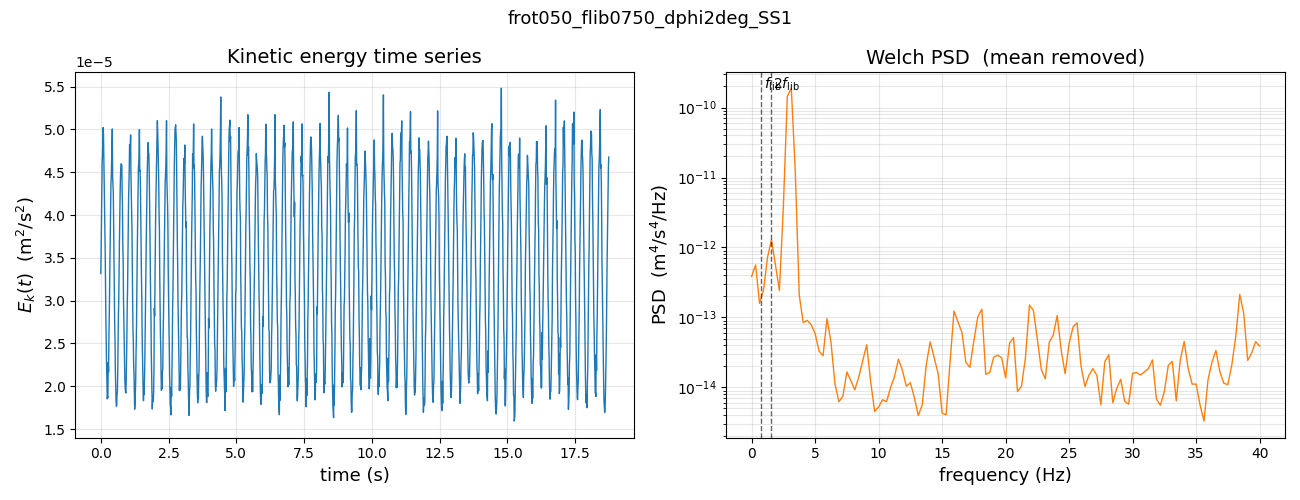

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: time series
axes[0].plot(t, ek, color="C0", lw=1)
axes[0].set_xlabel("time (s)", fontsize=13)
axes[0].set_ylabel(r"$E_k(t)$  (m$^2$/s$^2$)", fontsize=13)
axes[0].set_title("Kinetic energy time series", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Panel 2: PSD (Welch)
if LOGY:
    axes[1].semilogy(freq, pxx, color="C1", lw=1)
else:
    axes[1].plot(freq, pxx, color="C1", lw=1)
axes[1].set_xlabel("frequency (Hz)", fontsize=13)
axes[1].set_ylabel(r"PSD  (m$^4$/s$^4$/Hz)", fontsize=13)
ttl = "Welch PSD" + ("  (mean removed)" if DETREND else "")
axes[1].set_title(ttl, fontsize=14)
axes[1].grid(True, alpha=0.3, which="both")
if flib:
    for f, lbl in ((flib, r"$f_{\mathrm{lib}}$"),
                   (2 * flib, r"$2f_{\mathrm{lib}}$")):
        if f <= freq.max():
            axes[1].axvline(f, color="k", ls="--", lw=1, alpha=0.6)
            axes[1].annotate(lbl, xy=(f, 1), xycoords=("data", "axes fraction"),
                             xytext=(2, -12), textcoords="offset points",
                             fontsize=10)

fig.suptitle(run, fontsize=13)
fig.tight_layout()

if SAVE:
    output = OUTPUT or os.path.join(
        os.path.dirname(npz_path), "KineticEnergy_PSD.png")
    fig.savefig(output, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % output)

plt.show()